In [1]:
import pandas as pd
import numpy as np

# Load data
applications = pd.read_csv("../data/applications.csv")
candidates = pd.read_csv("../data/candidates.csv")
jobs = pd.read_csv("../data/jobs.csv")
sources = pd.read_csv("../data/sources.csv")
hires = pd.read_csv("../data/hires.csv")

print("Applications:", applications.shape)
print("Candidates:", candidates.shape)
print("Jobs:", jobs.shape)
print("Sources:", sources.shape)
print("Hires:", hires.shape)

Applications: (10000, 7)
Candidates: (2000, 8)
Jobs: (30, 7)
Sources: (15, 2)
Hires: (486, 5)


In [2]:
# Create hiring target
ml_data = applications.copy()

ml_data["hired"] = ml_data["application_id"].isin(
    hires["application_id"]
).astype(int)

print("Total applications:", len(ml_data))
print("Hired:", ml_data["hired"].sum())
print("Not hired:", (ml_data["hired"] == 0).sum())
print("Hiring rate:", round(ml_data["hired"].mean() * 100, 2), "%")

Total applications: 10000
Hired: 486
Not hired: 9514
Hiring rate: 4.86 %


In [3]:
# Merge data needed for prediction

ml_data = ml_data.merge(
    candidates[["candidate_id", "age", "experience_years", "highest_education"]],
    on="candidate_id",
    how="left"
)

ml_data = ml_data.merge(
    jobs[["job_id", "job_title", "department", "employment_type"]],
    on="job_id",
    how="left"
)

ml_data = ml_data.merge(
    sources[["source_id", "source_name"]],
    on="source_id",
    how="left"
)

print("ML dataset shape:", ml_data.shape)
print(ml_data.head())

ML dataset shape: (10000, 15)
   application_id  candidate_id  job_id  source_id  recruiter_id  \
0               1            29       2          1            19   
1               2           102      19         11             1   
2               3           123      14         11            18   
3               4            54       8          5            17   
4               5          1307      19          1             1   

  application_date application_status  hired  age  experience_years  \
0       2025-04-16           Rejected      0   35               4.3   
1       2025-07-22          Screening      0   30               1.7   
2       2025-10-30           Rejected      0   28               1.2   
3       2025-06-09          Interview      0   32               6.7   
4       2025-08-29            Applied      0   28               6.8   

  highest_education           job_title   department employment_type  \
0            M.Tech  Frontend Developer  Engineering       Ful

In [4]:
# Select features for the hiring prediction model

features = [
    "age",
    "experience_years",
    "highest_education",
    "job_title",
    "department",
    "employment_type",
    "source_name"
]

X = ml_data[features]
y = ml_data["hired"]

print("Features:", X.columns.tolist())
print("Target distribution:")
print(y.value_counts())

Features: ['age', 'experience_years', 'highest_education', 'job_title', 'department', 'employment_type', 'source_name']
Target distribution:
hired
0    9514
1     486
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Hires in training:", y_train.sum())
print("Hires in testing:", y_test.sum())

Training rows: 8000
Testing rows: 2000
Hires in training: 389
Hires in testing: 97


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "age",
    "experience_years"
]

categorical_features = [
    "highest_education",
    "job_title",
    "department",
    "employment_type",
    "source_name"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [7]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [8]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [9]:
# Generate predictions and probabilities

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

results = []

for model_name, predictions, probabilities in [
    ("Logistic Regression", logistic_pred, logistic_prob),
    ("Random Forest", rf_pred, rf_prob)
]:
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities)
    })

model_results = pd.DataFrame(results)

print(model_results.round(4))

                 Model  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
0  Logistic Regression    0.5295     0.0501  0.4845  0.0908   0.4983  0.0548
1        Random Forest    0.9355     0.0294  0.0103  0.0153   0.5410  0.0578


In [11]:
from sklearn.metrics import confusion_matrix

logistic_cm = confusion_matrix(y_test, logistic_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

print("\nRandom Forest Confusion Matrix:")
print(rf_cm)

Logistic Regression Confusion Matrix:
[[1012  891]
 [  50   47]]

Random Forest Confusion Matrix:
[[1870   33]
 [  96    1]]


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    predictions = (logistic_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4))

   Threshold  Precision  Recall      F1
0       0.10     0.0485  1.0000  0.0925
1       0.15     0.0485  1.0000  0.0925
2       0.20     0.0485  1.0000  0.0925
3       0.25     0.0485  1.0000  0.0926
4       0.30     0.0488  1.0000  0.0930
5       0.35     0.0480  0.9588  0.0914
6       0.40     0.0487  0.8969  0.0924
7       0.45     0.0492  0.7216  0.0922
8       0.50     0.0501  0.4845  0.0908


In [13]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold:")
print(best_threshold_row.round(4))

Best threshold:
Threshold    0.3000
Precision    0.0488
Recall       1.0000
F1           0.0930
Name: 4, dtype: float64


In [14]:
# Apply the selected probability threshold

best_threshold = 0.30

tuned_pred = (logistic_prob >= best_threshold).astype(int)

print("Selected threshold:", best_threshold)
print("Precision:", round(precision_score(y_test, tuned_pred), 4))
print("Recall:", round(recall_score(y_test, tuned_pred), 4))
print("F1 Score:", round(f1_score(y_test, tuned_pred), 4))

Selected threshold: 0.3
Precision: 0.0488
Recall: 1.0
F1 Score: 0.093


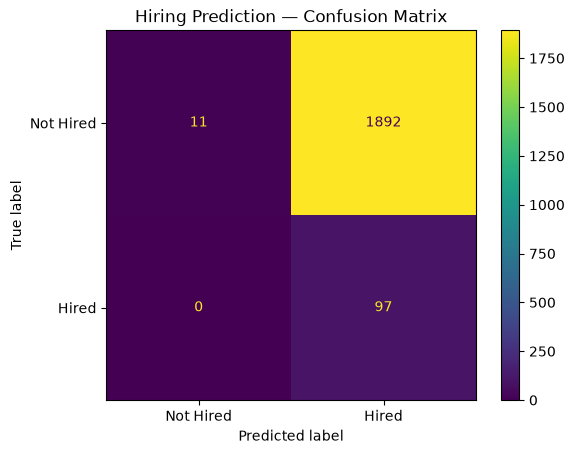

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_pred,
    display_labels=["Not Hired", "Hired"]
)

plt.title("Hiring Prediction — Confusion Matrix")
plt.show()

In [16]:
# Extract Logistic Regression feature importance

preprocessor_fitted = logistic_model.named_steps["preprocessor"]
model_fitted = logistic_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model_fitted.coef_[0]
})

importance_df["Absolute_Importance"] = importance_df["Coefficient"].abs()

importance_df = importance_df.sort_values(
    "Absolute_Importance",
    ascending=False
)

print(importance_df.head(15))

                             Feature  Coefficient  Absolute_Importance
35         cat__source_name_Job Fair    -0.608737             0.608737
28      cat__source_name_Consultancy     0.359951             0.359951
12       cat__job_title_Data Analyst     0.344719             0.344719
4      cat__highest_education_B.Tech    -0.284063             0.284063
38            cat__source_name_Other    -0.272676             0.272676
25        cat__source_name_AngelList     0.254616             0.254616
26    cat__source_name_Campus Hiring    -0.249223             0.249223
16    cat__job_title_Product Analyst    -0.247293             0.247293
17    cat__job_title_Product Manager     0.243118             0.243118
18  cat__job_title_Software Engineer    -0.215437             0.215437
31        cat__source_name_Glassdoor     0.214812             0.214812
32           cat__source_name_Hirect     0.178943             0.178943
27  cat__source_name_Company Website     0.169809             0.169809
2     

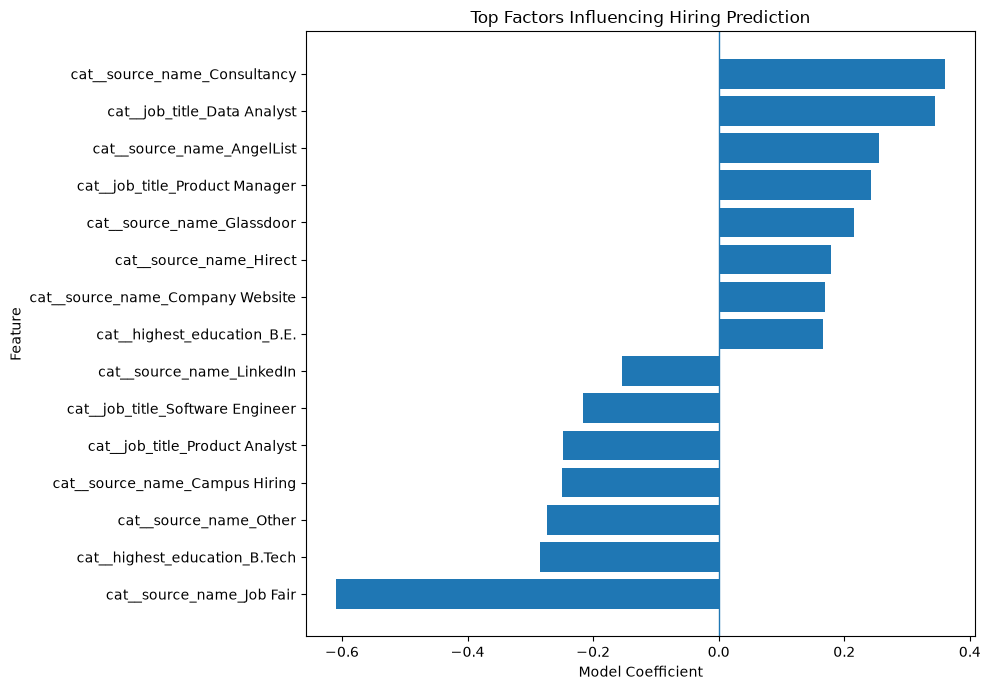

In [17]:
# Plot top 15 influential features

top_features = importance_df.head(15).sort_values("Coefficient")

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)
plt.xlabel("Model Coefficient")
plt.ylabel("Feature")
plt.title("Top Factors Influencing Hiring Prediction")
plt.tight_layout()
plt.show()

In [18]:
# Save ML results

model_results.to_csv("../ml/model_comparison_improved.csv", index=False)
threshold_df.to_csv("../ml/threshold_analysis.csv", index=False)
importance_df.to_csv("../ml/feature_importance_improved.csv", index=False)

print("ML results saved successfully.")

ML results saved successfully.


In [19]:
# Final ML summary

print("===== HIRING PREDICTION MODEL SUMMARY =====")
print()
print("Dataset size:", len(ml_data))
print("Hiring rate:", round(y.mean() * 100, 2), "%")
print()
print("Best tested threshold:", best_threshold)
print("Precision:", round(precision_score(y_test, tuned_pred), 4))
print("Recall:", round(recall_score(y_test, tuned_pred), 4))
print("F1 Score:", round(f1_score(y_test, tuned_pred), 4))
print()
print("Key finding:")
print(
    "The dataset is highly imbalanced, so accuracy alone is not a reliable "
    "measure of hiring prediction performance."
)

===== HIRING PREDICTION MODEL SUMMARY =====

Dataset size: 10000
Hiring rate: 4.86 %

Best tested threshold: 0.3
Precision: 0.0488
Recall: 1.0
F1 Score: 0.093

Key finding:
The dataset is highly imbalanced, so accuracy alone is not a reliable measure of hiring prediction performance.
